In [1]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [2]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown
!pip -q install pylhe

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 13.8 MB/s eta 0:00:00


In [10]:

import helpers as hp
importlib.reload(hp)

<module 'helpers' from '/content/helpers.py'>

In [ ]:
# ************************************************************
# Grab a coffe, this might take some time! (~17 min)
# ************************************************************

# ============================================================
# Execute Data Extraction
# ============================================================

# Standard Model (LO)
df_sm = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/SM/*/*.lhe.gz',
    label='SM',
    is_nlo=False
)

# VLF (NLO)
df_vlf = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/VLF/*/*.lhe.gz',
    label='VLF',
    is_nlo=True
)

# Scalar (NLO)
df_scalar = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/Scalar/*/*.lhe.gz',
    label='Scalar',
    is_nlo=True
)

# Zprime (LO)
df_zp = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/Zprime/*/*.lhe.gz',
    label='Zprime',
    is_nlo=False,
)

# Fake Data (NLO)
df_fake = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/FakeData/*/*.lhe.gz',
    label='FakeData',
    is_nlo=True
)

# Consolidate BSM models into a single DataFrame
df_bsm = pd.concat([df_vlf, df_scalar, df_zp, df_fake], ignore_index=True)

print("\n--- Direct LHE Extraction Complete ---")
print(f"SM Events Loaded:  {len(df_sm)}")
print(f"BSM Events Loaded: {len(df_bsm)}\n")

Loading SM from 1 LHE files...


KeyboardInterrupt: 

In [18]:
# ------------------------------------------------------------
# Automated Configuration (Using Best Fits)
# ------------------------------------------------------------
best_fits = {
    'VLF':    {'mPsiT': 1400., 'mSDM': 1300., 'scale_factor': 1.0},
    'Scalar': {'mST': 1000., 'mChi': 900., 'scale_factor': 1.0},
    'Zprime': {'mZp': 2800.,                'scale_factor': 1.0},
    'Zprime_20pc': {'mZp': 2600.,           'scale_factor': 1.0},
    'FakeData': {'scale_factor': 1.0}
}


sm_files = list(glob.glob('./drive/MyDrive/Full_Distributions/sm/Scalar/mPsiT_0_mSDM_0.npz'))


fake_data_files = (list(glob.glob('./drive/MyDrive/Full_Distributions/Scalar/bias_tunning3/mPsiT_1000_mSDM_900.npz'))
                    +list(glob.glob(f'./drive/MyDrive/Full_Distributions/Scalar/bias_tunning4/mPsiT_1000_mSDM_900.npz'))
                             )

vlf_files = (
    list(glob.glob(f'./drive/MyDrive/Full_Distributions/VLF/1/mPsiT_1400_mSDM_1300.npz')) + list(glob.glob(f'./drive/MyDrive/Full_Distributions/VLF/2/mPsiT_1400_mSDM_1300.npz'))
    + list(glob.glob(f'./drive/MyDrive/Full_Distributions/VLF/3/mPsiT_1400_mSDM_1300.npz'))
)

scalar_files = (
    list(glob.glob(f'./drive/MyDrive/Full_Distributions/Scalar/bias_tunning2/mPsiT_1000_mSDM_900.npz'))
    +list(glob.glob(f'./drive/MyDrive/Full_Distributions/Scalar/bias_tunning/mPsiT_1000_mSDM_900.npz'))
)


zp_files = list(glob.glob(f'./drive/MyDrive/Full_Distributions/Zprime/nlo/mZp_2800.npz'))
zp_20pc_files = list(glob.glob(f'./drive/MyDrive/Full_Distributions/Zprime_20pcW/1/mZp_2600.npz'))

print("\n--- Model Assembly Check ---")
print(f"VLF files loaded:         {len(vlf_files)}")
print(f"Scalar files loaded:      {len(scalar_files)}")
print(f"Zprime files loaded:      {len(zp_files)}")
print(f"Zprime_20pc files loaded: {len(zp_20pc_files)}")
print(f"Fake data files found:    {len(fake_data_files)}")
print(f"SM files found:           {len(sm_files)}\n")

# ------------------------------------------------------------
# Memory-Optimized Extraction Setup
# ------------------------------------------------------------
KEYS_TO_SUM = ['xsec (pb)', 'n_events']
KEYS_TO_KEEP = ['mTT', 'weights']

raw_data = {
    'FakeData':    {'arrays': {}, 'scalars': {}},
    'Scalar':      {'arrays': {}, 'scalars': {}},
    'VLF':         {'arrays': {}, 'scalars': {}},
    'Zprime':      {'arrays': {}, 'scalars': {}},
    'Zprime_20pc': {'arrays': {}, 'scalars': {}},
    'SM':          {'arrays': {}, 'scalars': {}}
}

# ------------------------------------------------------------
# Data Loading Loop
# ------------------------------------------------------------
all_files = list(set(vlf_files + scalar_files + zp_files + zp_20pc_files + sm_files + fake_data_files))

for f in all_files:
    aux = np.load(f, allow_pickle=True)
    print(aux['model'], aux['nevents'])
    if f in sm_files:
        model_name = 'SM'
    else:
        model_name = aux['model']

    if isinstance(model_name, np.ndarray):
        model_name = model_name.item() if model_name.size == 1 else model_name[0]
    if isinstance(model_name, bytes):
        model_name = model_name.decode('utf-8')

    targets = []

    if f in fake_data_files:
        targets.append(raw_data['FakeData'])

    if (model_name == '1-loop VLF' or model_name == 'VLF') and f in vlf_files:
        targets.append(raw_data['VLF'])
    elif (model_name == '1-loop Scalar' or model_name == 'Scalar' or model_name == 'Scalar (FF)') and f in scalar_files:
        targets.append(raw_data['Scalar'])
    elif model_name == 'Z prime' and f in zp_files:
        targets.append(raw_data['Zprime'])
    elif model_name == 'Z prime' and f in zp_20pc_files:
        targets.append(raw_data['Zprime_20pc'])
    elif model_name == 'SM' and f in sm_files:
        targets.append(raw_data['SM'])

    if not targets:
        aux.close()
        continue

    for target in targets:
        for key in aux.files:
            val = aux[key]
            if key in KEYS_TO_SUM:
                if key not in target['scalars']: target['scalars'][key] = 0.0
                target['scalars'][key] += float(val.item())
            elif val.ndim == 0 or val.size == 1:
                if not isinstance(val.item(), dict):
                    target['scalars'][key] = val.item()
            else:
                if key not in KEYS_TO_KEEP: continue
                if key not in target['arrays']: target['arrays'][key] = []
                target['arrays'][key].append(val[:])

    aux.close()

# Concatenate arrays
for model in raw_data:
    for key, list_of_arrays in raw_data[model]['arrays'].items():
        if list_of_arrays:
            raw_data[model]['arrays'][key] = np.concatenate(list_of_arrays, axis=0)

# ------------------------------------------------------------
# Post-Processing: Weights & Explicit High-Precision Normalization
# ------------------------------------------------------------
# Map each model to the number of files loaded
file_counts = {
    'FakeData':    len(fake_data_files),
    'Scalar':      len(scalar_files),
    'VLF':         len(vlf_files),
    'Zprime':      len(zp_files),
    'Zprime_20pc': len(zp_20pc_files),
    'SM':          len(sm_files)
}

for model_name, data in raw_data.items():
    arrs = data['arrays']
    if not arrs: continue

    # 1. Cast arrays to strict float64 immediately
    if 'weights' in arrs:
        arrs['weights'] = arrs['weights'].astype(np.float64)

        # Apply the division logic to ALL models based on file count
        num_files = file_counts.get(model_name, 1)
        if num_files > 0:
            arrs['weights'] /= num_files
            print(f"[{model_name:11}] Weights averaged over {num_files} file(s).")

    # 2. Scale Fake Data
    if model_name == 'FakeData' and 'weights' in arrs:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        arrs['weights'] = arrs['weights'] * factor_sq
        if factor_sq != 1.0:
            print(f"[{model_name:11}] Explicitly Scaled by {factor:.6e} to hit target.")

    # 3. Scale BSM models
    elif model_name in ['VLF', 'Scalar', 'Zprime', 'Zprime_20pc']:
        factor = np.float64(best_fits.get(model_name, {}).get('scale_factor', 1.0))
        factor_sq = factor ** 2
        if factor_sq != 1.0 and 'weights' in arrs:
            arrs['weights'] = arrs['weights'] * factor_sq
            print(f"[{model_name:11}] Scaled by Best-Fit factor: {factor:.6e}")

    # Rename securely
    if 'weights' in arrs: arrs['weight'] = arrs.pop('weights')
    if 'mTT' in arrs:     arrs['m_tt'] = arrs.pop('mTT')

# ------------------------------------------------------------
# Pure NumPy Assembly into DataFrames
# ------------------------------------------------------------
l_fake = len(raw_data['FakeData']['arrays'].get('weight', []))
l_s    = len(raw_data['Scalar']['arrays'].get('weight', []))
l_v    = len(raw_data['VLF']['arrays'].get('weight', []))
l_z    = len(raw_data['Zprime']['arrays'].get('weight', []))
l_z20  = len(raw_data['Zprime_20pc']['arrays'].get('weight', []))

final_dict = {}
labels_list = []
if l_fake > 0: labels_list.append(np.full(l_fake, 'FakeData'))
if l_s > 0:    labels_list.append(np.full(l_s, 'Scalar'))
if l_v > 0:    labels_list.append(np.full(l_v, 'VLF'))
if l_z > 0:    labels_list.append(np.full(l_z, 'Zprime'))
if l_z20 > 0:  labels_list.append(np.full(l_z20, 'Zprime_20pc'))

if labels_list:
    final_dict['label'] = np.concatenate(labels_list)

keys_to_stack = list(raw_data['SM']['arrays'].keys())

for key in keys_to_stack:
    arrs_to_concat = []
    if l_fake > 0 and key in raw_data['FakeData']['arrays']:    arrs_to_concat.append(raw_data['FakeData']['arrays'][key])
    if l_s > 0 and key in raw_data['Scalar']['arrays']:         arrs_to_concat.append(raw_data['Scalar']['arrays'][key])
    if l_v > 0 and key in raw_data['VLF']['arrays']:            arrs_to_concat.append(raw_data['VLF']['arrays'][key])
    if l_z > 0 and key in raw_data['Zprime']['arrays']:         arrs_to_concat.append(raw_data['Zprime']['arrays'][key])
    if l_z20 > 0 and key in raw_data['Zprime_20pc']['arrays']:  arrs_to_concat.append(raw_data['Zprime_20pc']['arrays'][key])

    if arrs_to_concat:
        final_dict[key] = np.concatenate(arrs_to_concat, axis=0)

df_bsm = pd.DataFrame(final_dict)

df_sm = pd.DataFrame(raw_data['SM']['arrays'])
if not df_sm.empty:
    df_sm['label'] = 'SM'

del raw_data, final_dict, labels_list
gc.collect()

print("\n--- DataFrame Assembly Complete ---")
print(f"BSM Events: {len(df_bsm)}")
print(f"SM Events:  {len(df_sm)}")


--- Model Assembly Check ---
VLF files loaded:         3
Scalar files loaded:      2
Zprime files loaded:      1
Zprime_20pc files loaded: 1
Fake data files found:    2
SM files found:           1

Scalar 3701262
VLF 3028859
Scalar 3688212
Scalar 3703160
VLF 2969907
Z prime 1000000
Scalar 3698700
VLF 2995381
Z prime 1308557
Scalar 3700881
[FakeData   ] Weights averaged over 2 file(s).
[Scalar     ] Weights averaged over 2 file(s).
[VLF        ] Weights averaged over 3 file(s).
[Zprime     ] Weights averaged over 1 file(s).
[Zprime_20pc] Weights averaged over 1 file(s).
[SM         ] Weights averaged over 1 file(s).

--- DataFrame Assembly Complete ---
BSM Events: 26106707
SM Events:  3688212


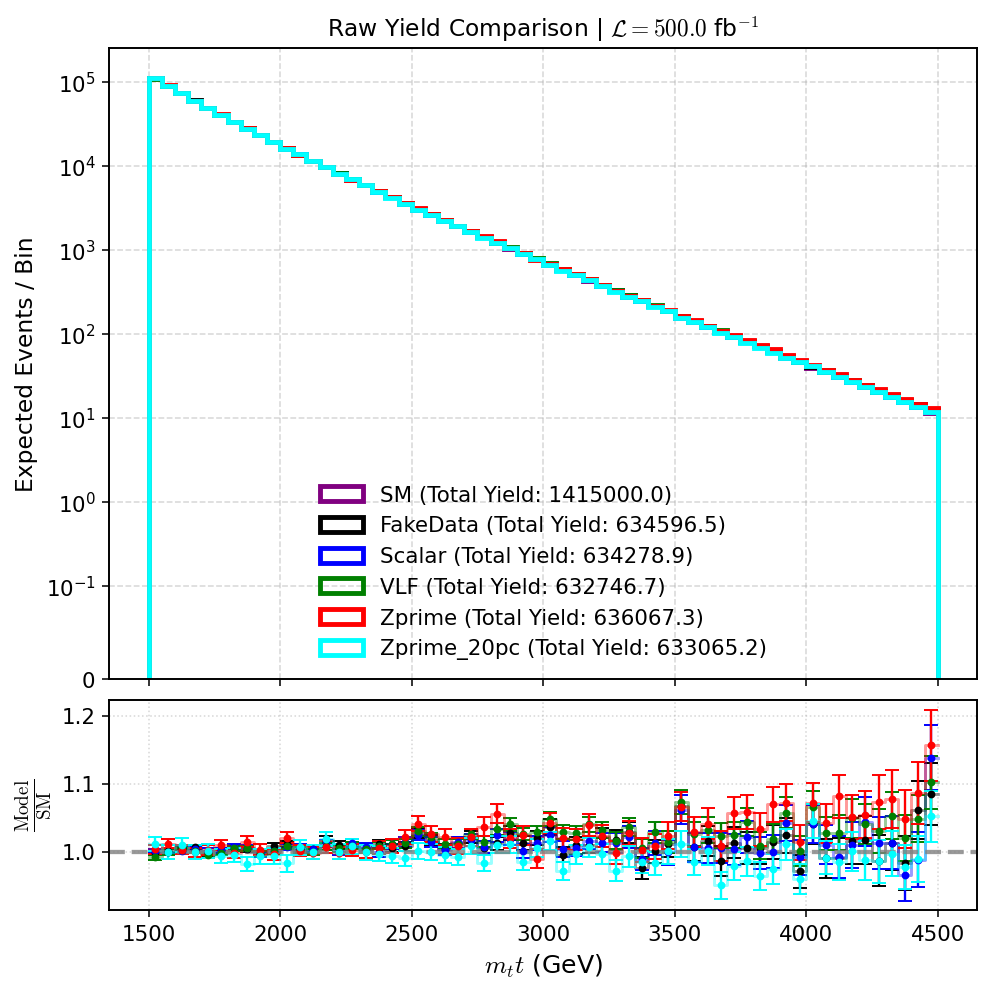

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.0):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    Negative weights (e.g., from NLO interference) are fully preserved.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime", "Zprime_20pc"]

    # --- Define Color Mapping Here ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'Zprime_20pc': 'cyan',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    # 1. Define explicit bin edges
    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # 2. Extract and Bin SM (Calculating Sum of Squared Weights for Error)
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'lbl': f"SM (Total Yield: {np.sum(w_sm):.1f})"}

    # 3. Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        # Determine specific error type based on Model vs Data
        if lab_str == 'FakeData':
            # Poisson statistical uncertainty for "Data"
            #err = np.sqrt(np.abs(h))
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)
        else:
            # MC Sum of Squared Weights for BSM Models
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': f"{lab_str} (Total Yield: {np.sum(h):.1f})"}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        # Get the assigned color, defaulting to 'gray' if not found
        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c)

        # Compute and plot the ratio to SM with Error Bars
        if lab_str != 'SM':
            with np.errstate(divide='ignore', invalid='ignore'):
                # 1. Calculate Ratio
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)

                # 2. Propagate Error: delta_R = (1/SM) * sqrt( err_BSM^2 + (Ratio * err_SM)^2 )
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / h_sm) * np.sqrt(data['err']**2 + (ratio**2 * hErr_sm**2)),
                    np.nan
                )

            # Plot error bars at bin centers
            ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, color=c,
                              fmt='o', ms=3, capsize=3.5, elinewidth=1.2)

            # Keep the faint step line connecting the points to match original aesthetic
            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=0.4)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    # Main Axes
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)

    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    # Ratio Axes
    ax_ratio.axhline(1.0, color='gray', linestyle='--', alpha=0.8) # Changed to 1.0 for standard ratio
    ax_ratio.set_xlabel(rf'${var}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{SM}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    #ax_ratio.set_ylim(0.9, 1.25)

    plt.tight_layout()
    plt.show()
# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [
    ("m_tt", (300, 5000)),
]

LUMI = 500.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=(1500,4500),
        density=False,
        sys_err=0.00
    )

In [20]:
# ------------------------------------------------------------
# m_cut Scan Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime"]
mcuts = [ 1500, 1800, 2000, 2200, 2500]
mcut_max = 4_500
bin_width = 100.0
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Luminosity Scan Configuration (Notebook)
# ------------------------------------------------------------
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]

# ------------------------------------------------------------
# Data Extraction
# ------------------------------------------------------------
var = "m_tt"  # Variable of the distributions

# Clean the DataFrames
df_sm_clean = df_sm[[var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_sm_clean = df_sm_clean[df_sm_clean[var] > 0]

df_hyp_clean = df_bsm[["label", var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_clean = df_hyp_clean[df_hyp_clean[var] > 0]

# Extract into pure NumPy dictionaries
sm_data = {
    "x": df_sm_clean[var].values,
    "w": df_sm_clean["weight"].values
}

bsm_data = {}
for lab, sub in df_hyp_clean.groupby("label"):
    lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if lab_str in labels:
        bsm_data[lab_str] = {
            "x": sub[var].values,
            "w": sub["weight"].values
        }

# ------------------------------------------------------------
# Load the m cut and luminosity scan data frames
# ------------------------------------------------------------
df_mcut = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                mcut_max=mcut_max, bin_width=bin_width,
                                L_target=L_target, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)

# Run the scan once to calculate both Shape and Falloff metrics but for luminosity
df_lumi = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=1500, mcut_max=4500,
                                bin_width=100.0, lumi_targets=lumi_targets, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)


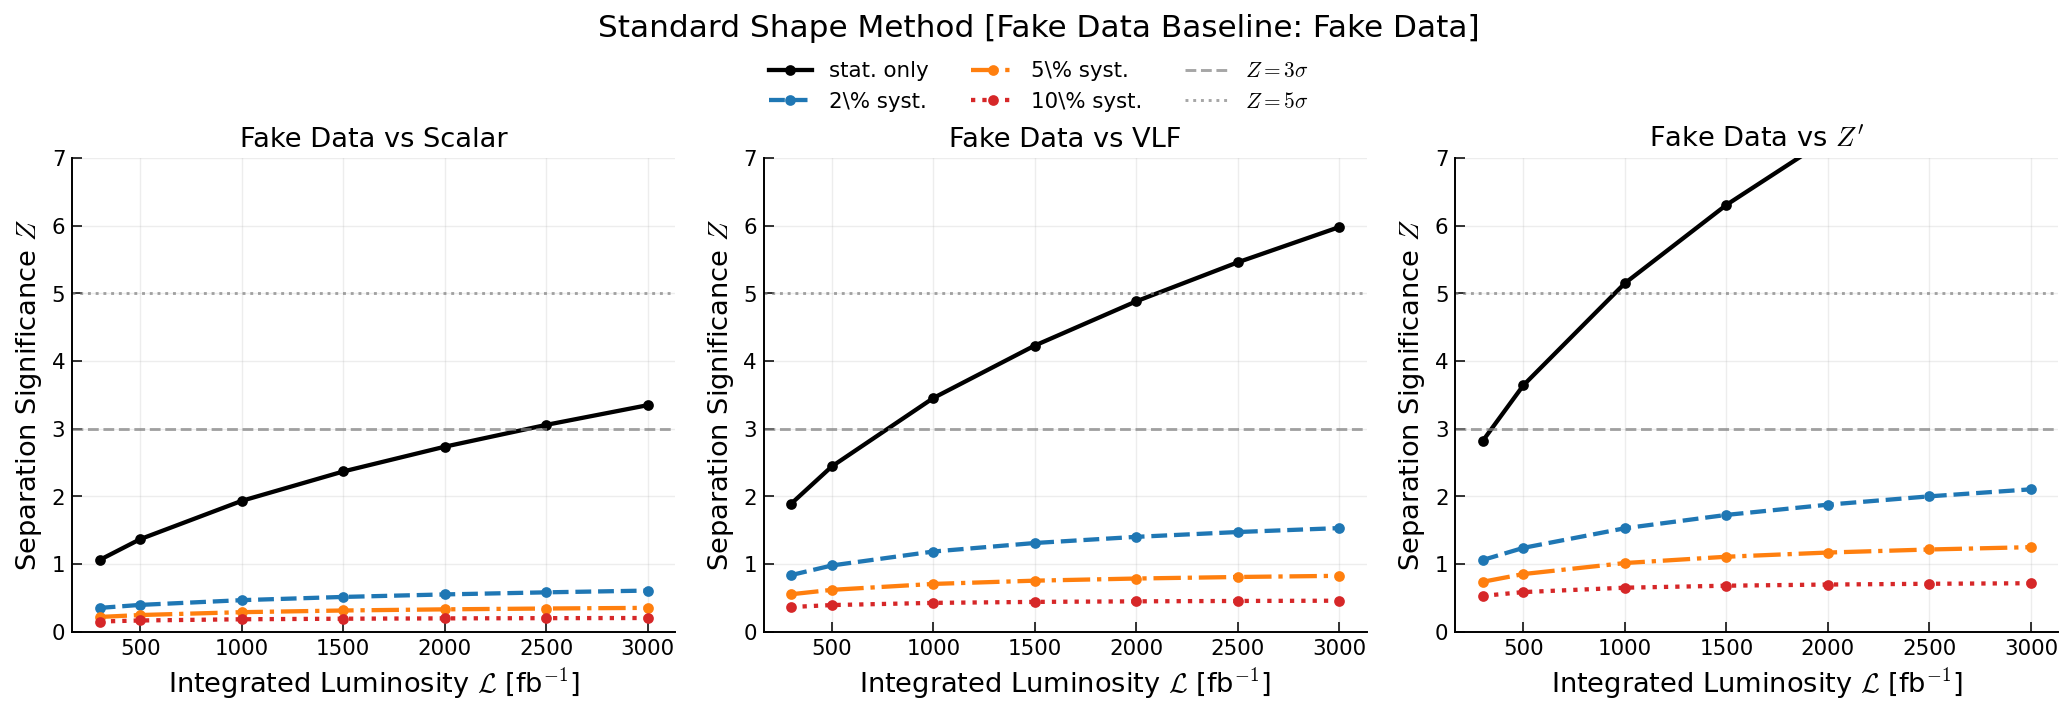

In [21]:
# Create output directory
outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)

#  Plot Mass Cut Scans
#hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="sh",
 #                      outfile=outdir / "syst_grid_mcut_shape.pdf",
  #                     fake_model='FakeData')

#hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="fa",
 #                      outfile=outdir / "syst_grid_mcut_falloff.pdf",
  #                     fake_model='FakeData')

# Plot Luminosity Scans
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_lumi_shape.pdf",
                       shareY = False, fake_model='FakeData')

#hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="fa",
                       #outfile=outdir / "syst_grid_lumi_falloff.pdf",
                       #shareY= False, fake_model='FakeData')


#hp.plot_ratio_pairwise(df_mcut, mcut_max, eps_values,
 #                      outfile=outdir / "improvement_ratio_mcut.pdf")

#hp.plot_ratio_pairwise_lumi(df_lumi, target_mcut=1500, eps_values=eps_values,
 #                           outfile=outdir / "improvement_ratio_lumi.pdf")


# This is the result from the signal and background generated separately

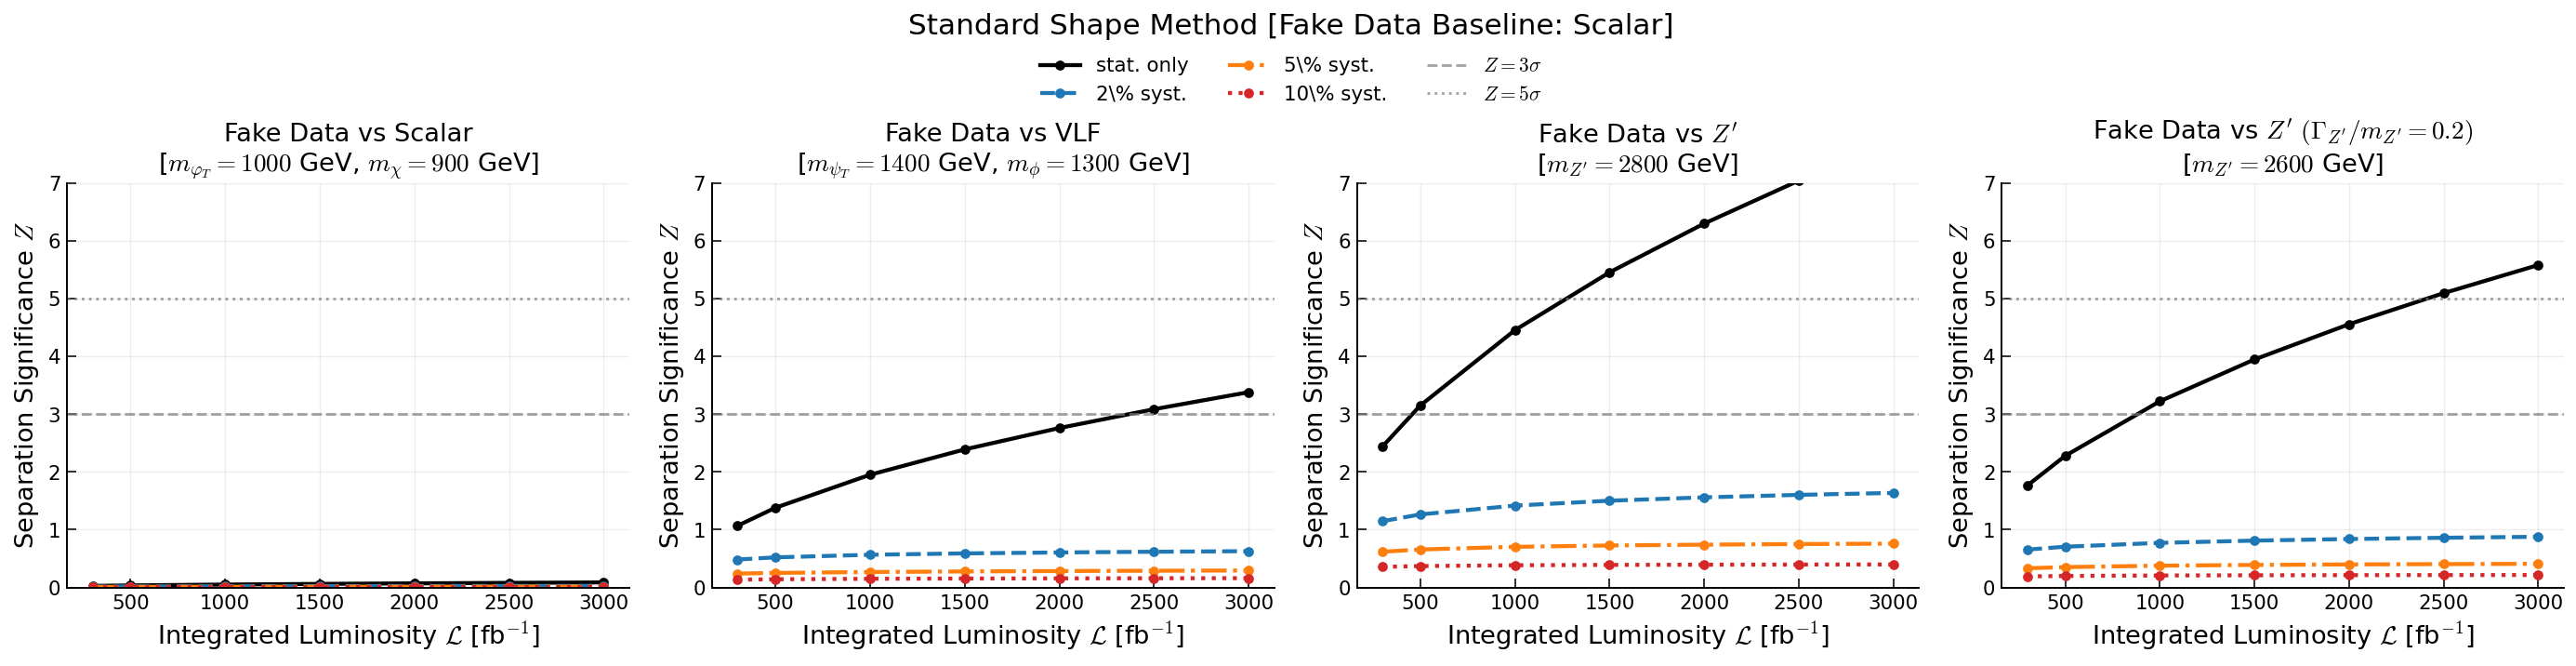

# Since the Fake Data is the Scalar model, we can look to the MC fluctuations comparing the bin-by-bin contribution to the Z^2 significance

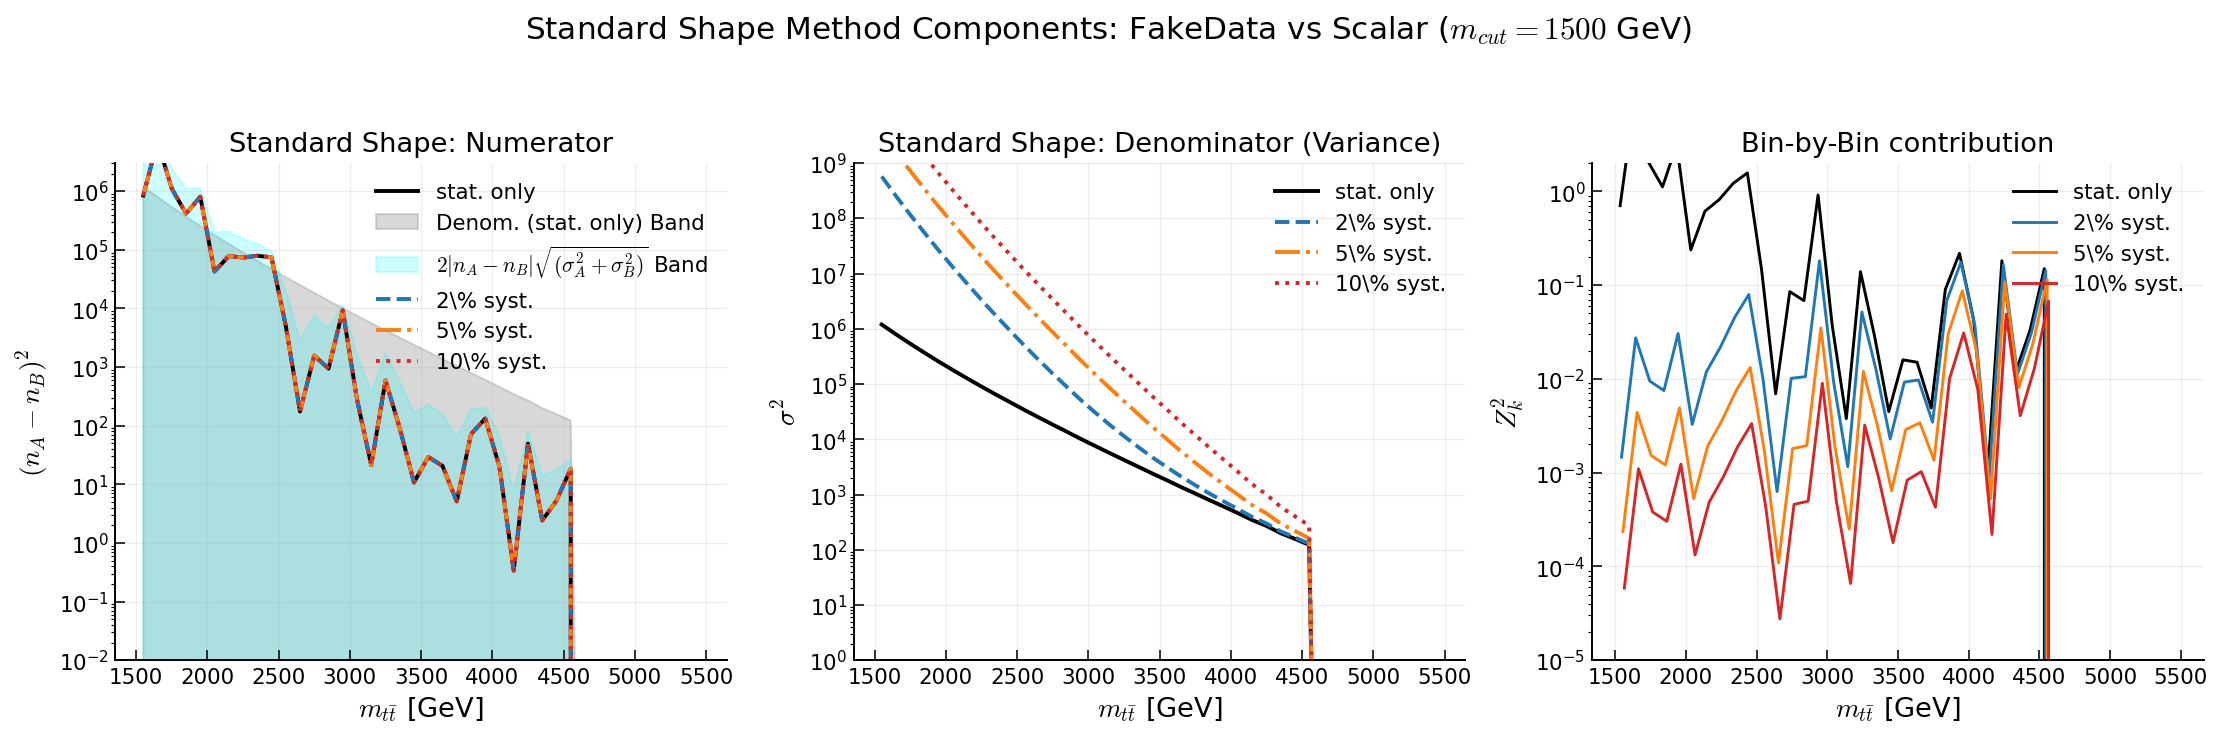

Data saved for pairs: ['FakeData vs Scalar', 'FakeData vs VLF', 'FakeData vs Zprime']


In [22]:
import numpy as np
import matplotlib.pyplot as plt
# Assuming 'hp' is your custom hep_stats module

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime", "Scalar (FF)"]
var = "m_tt"

target_mcut = 1500
target_pair = 'FakeData vs Scalar'

mcuts = [500, 1000, 1500, 1800, 2000, 2200, 2500, 3000]
bin_width = 100.0 # GeV
mcut_max = 5_500 # GeV
alpha = 1e-12
L_target = 3000.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# Define styles for the plots
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}

# Offsets for dodging the lines in the 3rd plot
offsets = {0.00: -15, 0.02: -5, 0.05: 5, 0.10: 15}

# ------------------------------------------------------------
# Data Preparation & Main Loop
# ------------------------------------------------------------
df_sm_work = df_sm[[var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_sm_work = df_sm_work[df_sm_work[var] > 0]

df_hyp_work = df_bsm[["label", var, "weight"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_work = df_hyp_work[df_hyp_work[var] > 0]

global_max = max(df_sm_work[var].max(), df_hyp_work[var].max())

component_store = {}

for mcut in mcuts:
    bin_edge_max = mcut_max if mcut_max is not None else global_max
    sm_mask = (df_sm_work[var] > mcut) & (df_sm_work[var] <= bin_edge_max)
    hyp_mask = (df_hyp_work[var] > mcut) & (df_hyp_work[var] <= bin_edge_max)

    df_sm_tail = df_sm_work[sm_mask].copy()
    df_hyp_tail = df_hyp_work[hyp_mask].copy()

    if len(df_sm_tail) == 0 or len(df_hyp_tail) == 0: continue

    bins = np.arange(mcut, bin_edge_max + bin_width, bin_width)

    # The universal luminosity scale factor
    lum_scale = L_target * 1000.0

    # Compute Standard Model yields and MC variance
    h_sm_raw, _ = np.histogram(df_sm_tail[var].values, bins=bins, weights=df_sm_tail["weight"].values)
    v_sm_raw, _ = np.histogram(df_sm_tail[var].values, bins=bins, weights=df_sm_tail["weight"].values**2)

    n_sm = h_sm_raw * lum_scale
    var_sm = v_sm_raw * (lum_scale**2)

    raw_templates = {}
    var_templates = {}

    for lab in labels:
        sub = df_hyp_tail[df_hyp_tail["label"] == lab]
        if len(sub) == 0:
            continue

        h_raw, _ = np.histogram(sub[var].values, bins=bins, weights=sub["weight"].values)
        v_raw, _ = np.histogram(sub[var].values, bins=bins, weights=sub["weight"].values**2)

        n_hyp = (h_raw * lum_scale)
        var_hyp = (v_raw * (lum_scale**2))

        raw_templates[lab] = n_hyp
        var_templates[lab] = var_hyp

    if 'FakeData' not in raw_templates: continue

    # Compare FakeData (A) against all other models (B)
    for lab in labels:
        if lab == 'FakeData' or lab not in raw_templates: continue

        a, b = 'FakeData', lab
        hA, hB = raw_templates[a], raw_templates[b]
        varA, varB = var_templates[a], var_templates[b]
        pair_name = f"{a} vs {b}"

        for eps in eps_values:
            _, num_sh, den_sh = hp.asimov_shape_Z_with_syst(hA, hB, frac_syst=eps, mode="test", eps=alpha)

            with np.errstate(divide='ignore', invalid='ignore'):
                # Standard error propagation
                term1 = 4 * varA
                term2_inner = 2 + (hA - hB) * (1 + 2 * (eps**2) * hB) / den_sh
                term2 = (term2_inner**2) * varB
                z2_err = np.abs((hA - hB) / den_sh) * np.sqrt(term1 + term2)
                z2_err = np.nan_to_num(z2_err, posinf=0, neginf=0)

                # NEW METRIC: Numerator / (varB + 2 * eps^2 * nB * varB)
                #custom_den = hB + (eps * hB)**2
                custom_den = varB + 2 * (eps**2) * hB * varB
                custom_metric = np.nan_to_num(num_sh / custom_den, posinf=0, neginf=0)

                # CALCULATION FOR NEW SHADED BAND
                num_band = 2 * np.abs((hA - hB)) * np.sqrt(varA + varB)


            if mcut not in component_store: component_store[mcut] = {}
            if pair_name not in component_store[mcut]: component_store[mcut][pair_name] = {}

            component_store[mcut][pair_name][eps] = {
                "num_sh": num_sh,
                "den_sh": den_sh,
                "z2_err": z2_err,
                "custom_metric": custom_metric,
                "num_band": num_band,
                "bins": bins
            }

# ------------------------------------------------------------
# Plotting Functions
# ------------------------------------------------------------
if target_mcut not in component_store or target_pair not in component_store[target_mcut]:
    print(f"Data not available for {target_pair} at {target_mcut} GeV.")
else:
    fig_sh, axes_sh = plt.subplots(1, 3, figsize=(16, 5))

    for eps_syst in eps_values:
        if eps_syst not in component_store[target_mcut][target_pair]: continue
        comp = component_store[target_mcut][target_pair][eps_syst]
        b = comp["bins"]
        centers = 0.5 * (b[:-1] + b[1:])

        color, ls = syst_styles.get(eps_syst, ("black", "-"))
        label = "stat. only" if eps_syst == 0.0 else rf"{int(100*eps_syst)}\% syst."
        x_offset = offsets.get(eps_syst, 0)

        # Plot Numerator
        axes_sh[0].plot(centers, comp["num_sh"], color=color, linestyle=ls, linewidth=2, label=label)

        # NEW SHADED BANDS FOR STAT. ONLY CASE IN THE FIRST PLOT
        if eps_syst == 0.0:
            # Filled band for denominator
            axes_sh[0].fill_between(centers, 1e-2, comp["den_sh"], color='gray', alpha=0.3, label="Denom. (stat. only) Band")

            # Filled band for 4*(hA - hB)**2 * (varA + varB)
            axes_sh[0].fill_between(centers, 1e-2, comp["num_band"], color='cyan', alpha=0.2, label=r"$2|n_A-n_B|\sqrt{(\sigma_A^2+\sigma_B^2)}$ Band")
            #axes_sh[0].errorbar(centers, comp["num_sh"],yerr = comp["num_band"], color='black', capsize = 3, label=r"$2|n_A-n_B|\sqrt{(\sigma_A^2+\sigma_B^2)}$ Band")

        # Plot Standard Denominator
        axes_sh[1].plot(centers, comp["den_sh"], color=color, linestyle=ls, linewidth=2, label=label)

        # Plot the Custom Metric in the 3rd panel
        custom_val = comp["num_sh"]/comp["den_sh"]
        axes_sh[2].plot(centers + x_offset, custom_val, color=color, linewidth=1.5, label=label)

    axes_sh[0].set_title("Standard Shape: Numerator")
    axes_sh[0].set_ylabel(r"$(n_A - n_B)^2$")
    axes_sh[0].set_yscale('log')
    axes_sh[0].set_ylim([1e-2, 3e+6])

    axes_sh[1].set_title("Standard Shape: Denominator (Variance)")
    axes_sh[1].set_ylabel(r"$\sigma^2$")
    axes_sh[1].set_yscale('log')
    axes_sh[1].set_ylim([1e+0, 1e+9])

    # Updated Title/Labels for Panel 3
    axes_sh[2].set_title("Bin-by-Bin contribution")
    #axes_sh[2].set_ylabel(r"$\frac{(n_A - n_B)^2}{\sigma^2_{B}}$")
    axes_sh[2].set_ylabel(r"$Z_k^2$")
    axes_sh[2].set_yscale('log')
    axes_sh[2].set_ylim([1e-5,2])

    for ax in axes_sh:
        ax.set_xlabel(rf"$m_{{t\bar t}}$ [GeV]")
        hp.beautify_axis(ax, grid=True)
        ax.legend(loc="upper right")

    fig_sh.suptitle(f"Standard Shape Method Components: {target_pair} ($m_{{cut}} = {target_mcut}$ GeV)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig('components_standard_shape.pdf', bbox_inches='tight')
    plt.show()

    # Final Data Export
    shape_data = {}
    for current_pair in component_store[target_mcut].keys():
        shape_data[current_pair] = {}
        for eps_syst in eps_values:
            if eps_syst not in component_store[target_mcut][current_pair]: continue
            comp = component_store[target_mcut][current_pair][eps_syst]


            shape_data[current_pair][eps_syst] = {
                'top': comp["num_sh"],
                'bot': comp["den_sh"],
                'z2': np.nan_to_num(comp["num_sh"] / comp["den_sh"], posinf=0, neginf=0),
                'z2_err': comp["z2_err"],
                'custom_metric': comp["custom_metric"],
                'num_band': comp["num_band"]
            }

    print(f"Data saved for pairs: {list(shape_data.keys())}")

# Generating Background and signal separately:

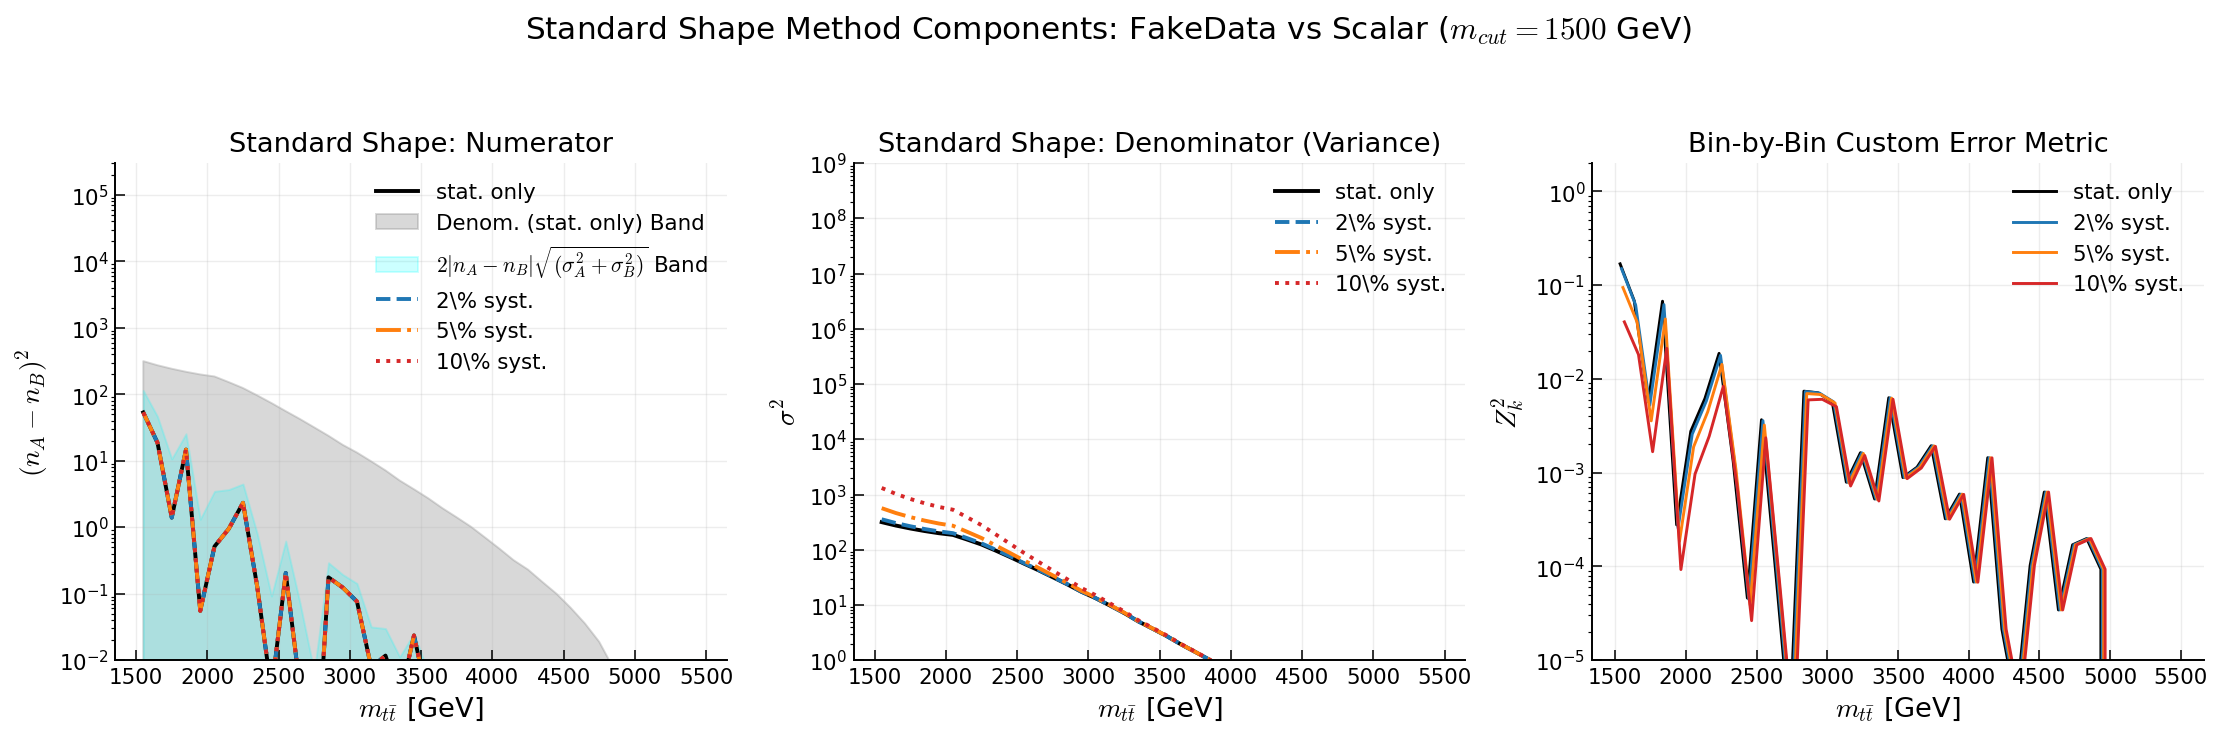